In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Charger les données
df = pd.read_csv('/home/jovyan/work/ventes_retail.csv')

print(f"✅ Données chargées : {len(df):,} lignes, {len(df.columns)} colonnes")
df.head()

✅ Données chargées : 100,000 lignes, 24 colonnes


,sale_id,date,year,month,quarter,product_name,category,sub_category,brand,store_name,...,customer_name,age_group,segment,quantity,unit_price,discount_pct,total_ht,total_ttc,cost_price,gross_margin
0,1,2022-08-17,2022,8,3,Rencontre Tablettes,Électronique,Tablettes,NordPlus,RetailTN Nabeul 1,...,Eugène-Alfred Robert,50+,Gold,8,115.93,3.0,899.62,1070.55,72.13,322.58
1,2,2022-03-03,2022,3,1,Impression Laptops,Électronique,Laptops,NordPlus,RetailTN Nabeul 4,...,Sylvie Tessier,50+,Bronze,17,483.60,17.0,6823.60,8120.08,297.32,1769.16
2,3,2023-07-24,2023,7,3,Horizon Laptops,Électronique,Laptops,MedStore,RetailTN Ben Arous 1,...,Paul Foucher de la Camus,50+,Gold,14,275.50,5.0,3664.15,4360.34,189.31,1013.81
3,4,2024-01-06,2024,1,1,Ancien Boulangerie,Alimentation,Boulangerie,SudMarket,RetailTN Manouba 1,...,Juliette du Bazin,36-50,Bronze,2,585.14,16.0,983.04,1169.82,404.88,173.28
4,5,2024-01-11,2024,1,1,Rapport Football,Sport,Football,TunisiaShop,RetailTN Ben Arous 2,...,Frédérique Olivier de la Maillot,50+,Silver,3,41.43,7.0,115.59,137.55,20.17,55.08


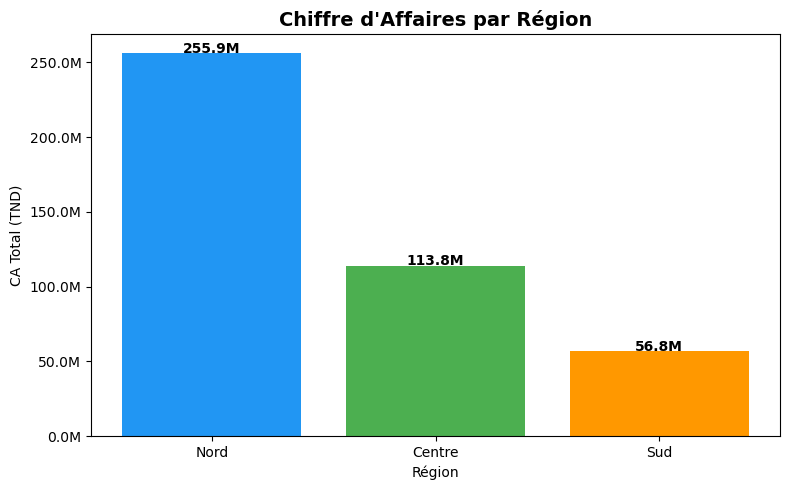

✅ Graphique 1 sauvegardé


In [2]:
# ── Graphique 1 : CA par Région ──
ca_region = df.groupby('region')['total_ttc'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ca_region.index, ca_region.values, color=['#2196F3', '#4CAF50', '#FF9800'])
ax.set_title('Chiffre d\'Affaires par Région', fontsize=14, fontweight='bold')
ax.set_xlabel('Région')
ax.set_ylabel('CA Total (TND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for bar, val in zip(bars, ca_region.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500000,
            f'{val/1e6:.1f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/jovyan/work/ca_region.png', dpi=150)
plt.show()
print("✅ Graphique 1 sauvegardé")

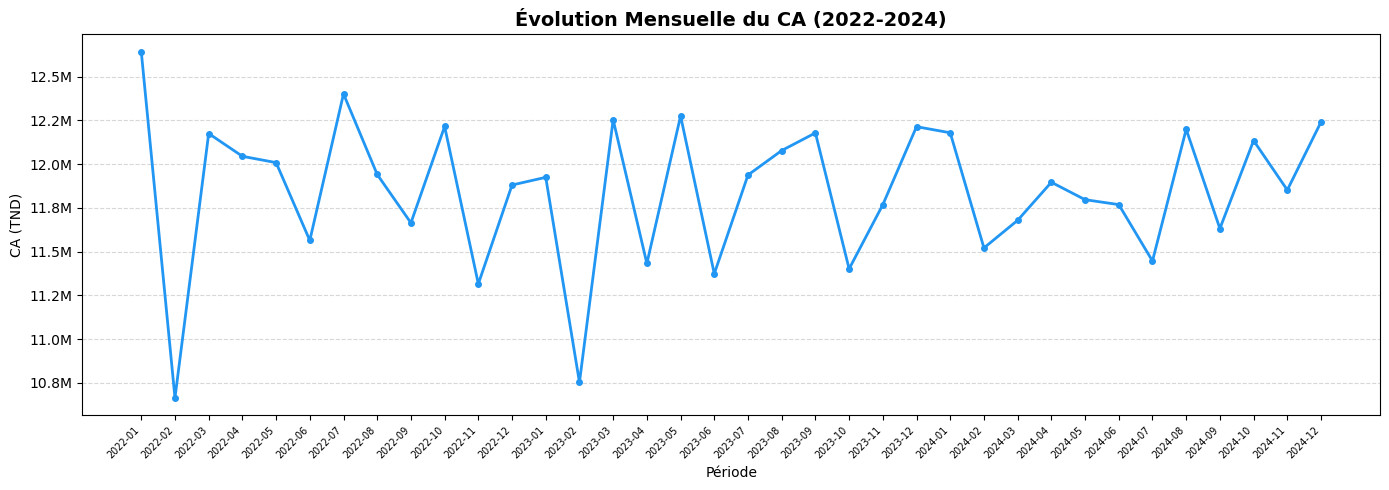

✅ Graphique 2 sauvegardé


In [3]:
# ── Graphique 2 : Évolution mensuelle du CA ──
df['date'] = pd.to_datetime(df['date'])
evolution = df.groupby(['year', 'month'])['total_ttc'].sum().reset_index()
evolution['periode'] = evolution['year'].astype(str) + '-' + evolution['month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(evolution['periode'], evolution['total_ttc'], 
        color='#2196F3', linewidth=2, marker='o', markersize=4)
ax.set_title('Évolution Mensuelle du CA (2022-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Période')
ax.set_ylabel('CA (TND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right', fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/home/jovyan/work/evolution_ca.png', dpi=150)
plt.show()
print("✅ Graphique 2 sauvegardé")

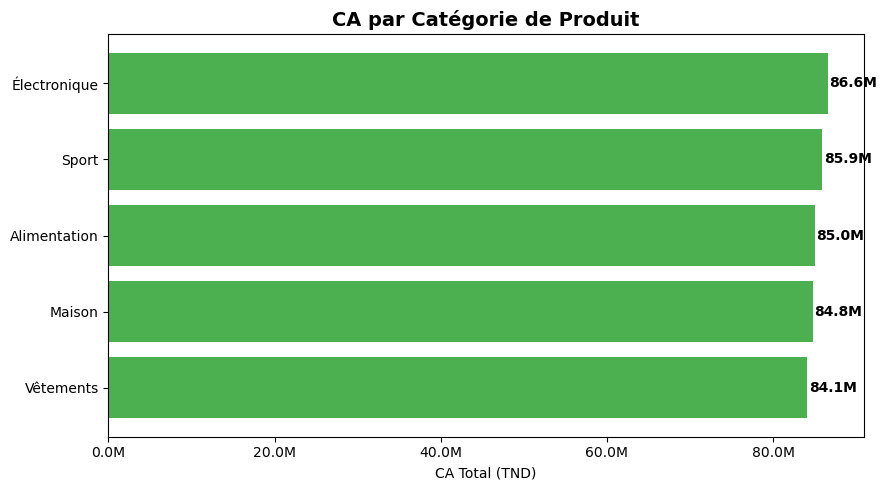

✅ Graphique 3 sauvegardé


In [4]:
# ── Graphique 3 : CA par Catégorie ──
ca_cat = df.groupby('category')['total_ttc'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(ca_cat.index, ca_cat.values, color='#4CAF50')
ax.set_title('CA par Catégorie de Produit', fontsize=14, fontweight='bold')
ax.set_xlabel('CA Total (TND)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for bar, val in zip(bars, ca_cat.values):
    ax.text(bar.get_width() + 200000, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/jovyan/work/ca_categorie.png', dpi=150)
plt.show()
print("✅ Graphique 3 sauvegardé")

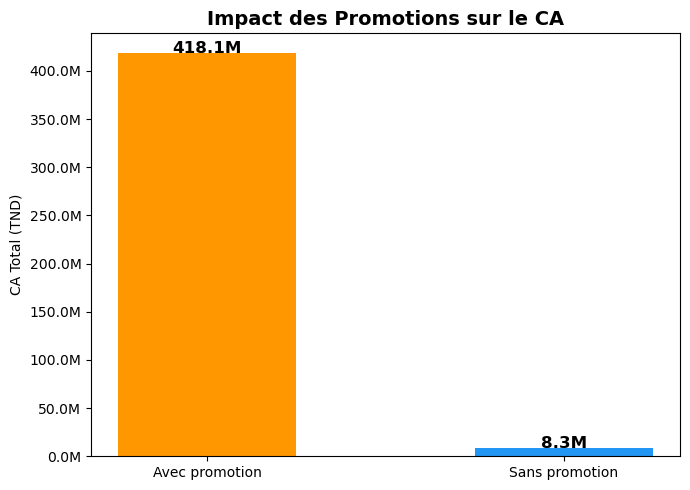

✅ Graphique 4 sauvegardé


In [5]:
# ── Graphique 4 : Impact des Promotions ──
df['promo'] = df['discount_pct'].apply(lambda x: 'Avec promotion' if x > 0 else 'Sans promotion')
promo = df.groupby('promo')['total_ttc'].sum()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(promo.index, promo.values, color=['#FF9800', '#2196F3'], width=0.5)
ax.set_title('Impact des Promotions sur le CA', fontsize=14, fontweight='bold')
ax.set_ylabel('CA Total (TND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for bar, val in zip(bars, promo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500000,
            f'{val/1e6:.1f}M', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/jovyan/work/impact_promo.png', dpi=150)
plt.show()
print("✅ Graphique 4 sauvegardé")


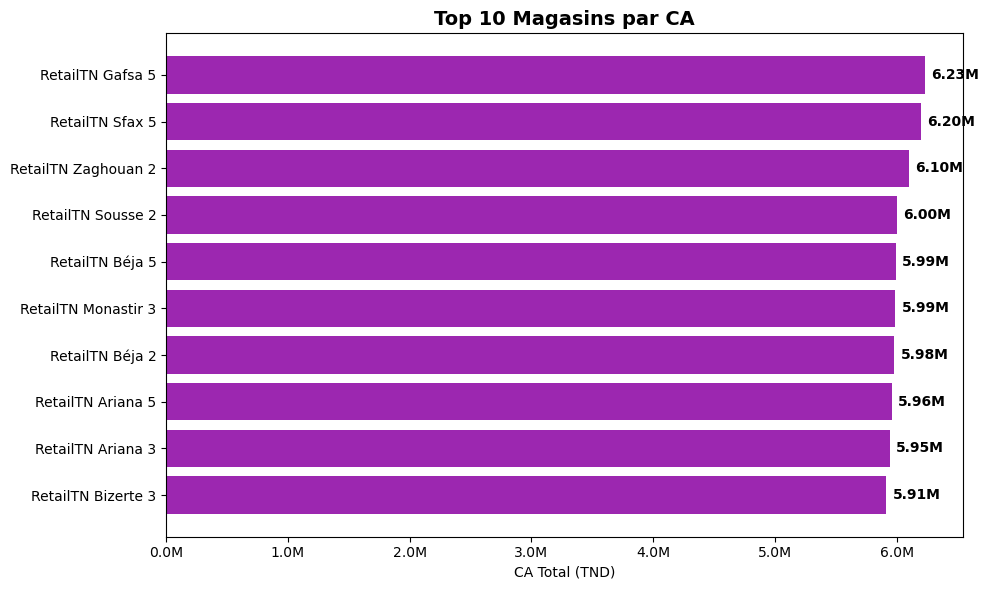

✅ Graphique 5 sauvegardé


In [6]:
# ── Graphique 5 : Top 10 Magasins par CA ──
top_magasins = df.groupby('store_name')['total_ttc'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_magasins.index[::-1], top_magasins.values[::-1], color='#9C27B0')
ax.set_title('Top 10 Magasins par CA', fontsize=14, fontweight='bold')
ax.set_xlabel('CA Total (TND)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for bar, val in zip(bars, top_magasins.values[::-1]):
    ax.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.2f}M', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/jovyan/work/top_magasins.png', dpi=150)
plt.show()
print("✅ Graphique 5 sauvegardé")

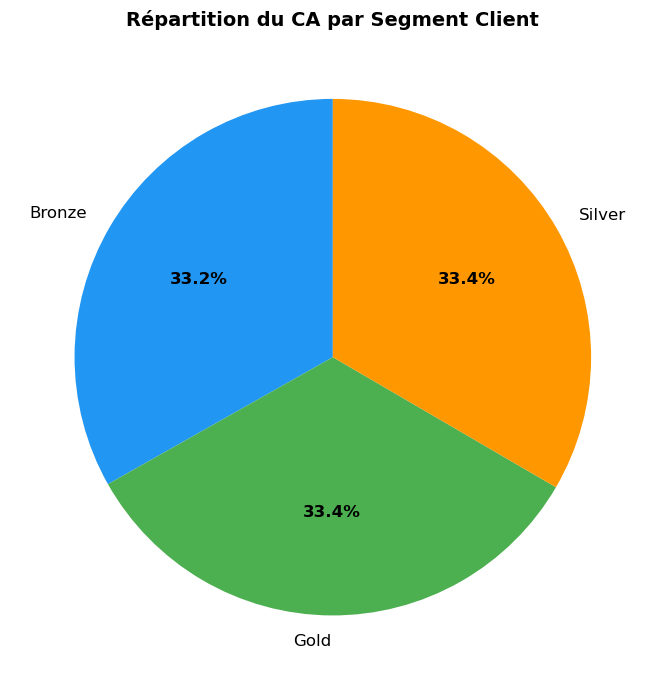

✅ Graphique 6 sauvegardé


In [7]:
# ── Graphique 6 : Répartition par Segment Client ──
segment = df.groupby('segment')['total_ttc'].sum()

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800']
wedges, texts, autotexts = ax.pie(
    segment.values,
    labels=segment.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('Répartition du CA par Segment Client', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/jovyan/work/segment_client.png', dpi=150)
plt.show()
print("✅ Graphique 6 sauvegardé")